In [1]:
# --- Check and install Pyomo if not present ---
%pip install pyomo


   ━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━ 2.1/4.4 MB 1.4 MB/s eta 0:00:02m
Resuming download pyomo-6.9.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (2.1 MB/4.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 1.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyomo]32m1/2 [pyomo]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pyomo.environ import *
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict

def make_nonzero_BIP(num_vars, num_constraints, seed=368):
    """
    Generate a minimization BIP with nonzero optimal solution.
    Ensures all-zero x is infeasible (b > 0) and feasible x with 1s exists.
    """
    rng = np.random.RandomState(seed + num_vars)

    c = rng.randint(1, 20, size=num_vars)  # positive costs
    A = rng.randint(0, 10, size=(num_constraints, num_vars))

    # Choose a feasible x with some 1s
    x_feasible = rng.randint(0, 2, size=num_vars)
    if x_feasible.sum() < 2:
        # ensure at least two 1's for stronger structure
        ones = rng.choice(num_vars, size=2, replace=False)
        x_feasible[ones] = 1

    # Set b so that x_feasible satisfies A x >= b
    b = A.dot(x_feasible)
    # Add positive RHS so x=0 is infeasible
    b = np.maximum(b - rng.randint(0, 3, size=b.shape), 1)

    return c, A, b, x_feasible



def solve_bip_normally(c, A, b, solver = "cbc"):
    N = len(c)
    model = ConcreteModel()

    # Variables
    model.x = Var(range(N), within=Binary)

    # Objective
    model.obj = Objective(expr=sum(c[i] * model.x[i] for i in range(N)),
                          sense=minimize)

    # Constraints: A x >= b
    M = len(A)
    model.constraints = ConstraintList()
    for j in range(M):
        model.constraints.add(
            sum(A[j][i] * model.x[i] for i in range(N)) >= b[j]
        )

    # Coverage constraint
    model.constraints.add(sum(model.x[i] for i in range(N)) >= 1)

    # Solver
    solver_obj = SolverFactory(solver)
    result = solver_obj.solve(model, tee=False)

    # Extract solution
    #status = result.solver.status.value
    tc = result.solver.termination_condition
    x_val = [int(model.x[i].value) for i in range(N)]
    obj_val = model.obj()

    return tc, x_val, obj_val





In [2]:
c, A, b, x_feas = make_nonzero_BIP(5,5)
tc, x_opt, obj_opt = solve_bip_normally(c, A, b, solver= "cbc")
print("c =", c)
print("b =", b)
print("A =\n", A)
print("known feasible =", x_feas)
print("Optimal:", x_opt, "Obj =", obj_opt, "Status =", tc)


c = [15 10 15  3 10]
b = [21  2 16 21  8]
A =
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]
known feasible = [0 1 1 0 1]
Optimal: [0, 1, 1, 0, 1] Obj = 35.0 Status = optimal


In [3]:
# --- Generate valid vectors ---
def generate_valid_vectors(N):
    """Generate all 0/1 lists with the constraint: if vec[i] == 1, then vec[N+i] must be 1."""
    for vec in itertools.product([0, 1], repeat=2 * N):
        if all(not (vec[i] == 1 and vec[i + N] == 0) for i in range(N)):
            yield list(vec)  # convert tuple → mutable list


def solve_bip(vec, c, A, b, solver="cbc"):
    N = len(c)
    model = ConcreteModel()

    # Variables with bounds from vec
    model.x = Var(range(N), within=Binary)
    for i in range(N):
        model.x[i].setlb(vec[i])
        model.x[i].setub(vec[i + N])

    # Objective
    model.obj = Objective(expr=sum(c[i] * model.x[i] for i in range(N)),
                          sense=minimize)

    # Constraints: A x >= b
    M = len(A)
    model.constraints = ConstraintList()
    for j in range(M):
        model.constraints.add(
            sum(A[j][i] * model.x[i] for i in range(N)) >= b[j]
        )

    # Solve
    solver_obj = SolverFactory(solver)
    result = solver_obj.solve(model, tee=False)

    #status = result.solver.status.value
    tc = result.solver.termination_condition
    from pyomo.opt import TerminationCondition

    if result.solver.termination_condition in [TerminationCondition.optimal,
                                            TerminationCondition.locallyOptimal,
                                            TerminationCondition.feasible]:
        x_val = [int(model.x[i].value) for i in range(N)]
        obj_val = model.obj()
    else:
        x_val = None
        obj_val = None
    return tc, obj_val, x_val



# --- Initialize global structures ---
Q = defaultdict(lambda: defaultdict(float))
v = defaultdict(float)
results = defaultdict(tuple)



In [4]:
# --- Q-learning Value Function ---
def value_function(vec):
    """
    Update Q-values and value function v for a given state vector vec.
    vec: list of length 2*N representing current branching state.
    """
    if results[tuple(vec)][0] == None or results[tuple(vec)][1] == None:
        v[tuple(vec)] = -1000000
        results[tuple(vec)][3] = -1000000
        return 0.0,0.0
    N = len(vec) // 2
    vecL = vec.copy()
    vecR = vec.copy()

    diff_sum = 0.0  # <-- track average diff for plotting
    for i in range(N):
        # Left action: fix variable i to 0
        vecL[i] = 0
        vecL[i + N] = 0
        # Right action: fix variable i to 1
        vecR[i] = 1
        vecR[i + N] = 1

        # Compute Q-values
        if results[tuple(vecL)][0] == None:
            diffL = 0
            diffR = abs(results[tuple(vec)][0] - results[tuple(vecR)][0])
        elif results[tuple(vecR)][0] == None:
            diffR = 0
            diffL = abs(results[tuple(vec)][0] - results[tuple(vecL)][0])
        elif results[tuple(vecL)][0] == None and results[tuple(vecR)][0] == None :
            diffL = 0
            diffR = 0
        else: 
            diffL = abs(results[tuple(vec)][0] - results[tuple(vecL)][0])
            diffR = abs(results[tuple(vec)][0] - results[tuple(vecR)][0])
            
        diff_sum += (diffL + diffR) / 2.0  # average over both branches
        Q[tuple(vec)][(i, 'L')] = diffL + v[tuple(vecL)]
        Q[tuple(vec)][(i, 'R')] = diffR + v[tuple(vecR)]

    # Update value function v
    #v_delta = v[tuple(vec)]
    v[tuple(vec)] = max(Q[tuple(vec)].values(), default=0.0)
    results[tuple(vec)][3] = max(Q[tuple(vec)].values(), default=0.0)
    #delta = max(delta,abs(v_delta - v[tuple(vec)]))
    # Return mean of average differences for this vec
    return v[tuple(vec)],diff_sum / N if N > 0 else 0.0


Objective coefficients (c): [15 10 15  3 10]

Constraint matrix (A):
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]

RHS vector (b): [21  2 16 21  8]
Number of binary variables: 5
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
model.name="unknown";
    - termination condition: infeasible
    - message from solver: <und

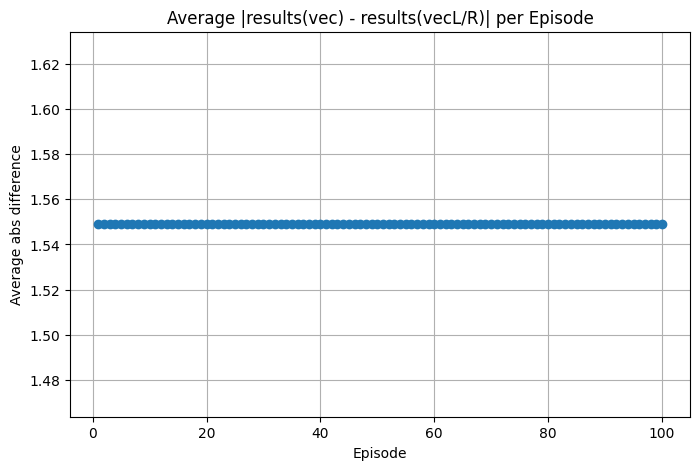

In [7]:
import numpy as np
# --- Define a small test instance ---
c, A, b, x_feas = make_nonzero_BIP(5, 5)
N = len(c)
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
print("Number of binary variables:", N)



# Solving the optimization problem corresponding to each state
for vec in generate_valid_vectors(N):
    tc,obj_val,x_val = solve_bip(vec, c, A, b)
    compact = []
    for i in range(N//2):
             if vec[i] == vec[i + N]:
              compact.append(vec[i])
             else:
              compact = []
              break
    if tc == 'infeasible':
        results[tuple(vec)] = [obj_val , x_val,  'I', None, None]
    elif tc == 'optimal' and  x_opt == compact:
        v[tuple(vec)] = 1000000
        results[tuple(vec)] = [obj_val , x_val, 'O', 1000000, None]
    elif tc == 'locallyOptimal':
        results[tuple(vec)] = [obj_val , x_val, 'lo', None, None]
    #elif tc == 'feasible':
     #   results[tuple(vec)] = [obj_val , x_val, 'F', None, None]
    elif tc == 'unbounded':
        results[tuple(vec)] = [obj_val , x_val, 'U', None, None]
    else:
        results[tuple(vec)] = [obj_val , x_val, 'F', None, None]
# --- Main Learning Loop ---
avg_diffs_per_episode = []

for episode in range(100):
    vec_diffs = []

    for vec in generate_valid_vectors(N):
        #obj_val = solve_bip(vec, c, A, b)
        #results[tuple(vec)] = obj_val

        _, avg_diff_vec = value_function(vec)
        vec_diffs.append(avg_diff_vec)

    # Mean of all vec differences for this episode
    # Filter out None values
    filtered_diffs = [diff for diff in vec_diffs if diff is not None]

    # Calculate the average only if the filtered list is not empty
    if filtered_diffs:
      average_diff = sum(filtered_diffs) / len(filtered_diffs)
      avg_diffs_per_episode.append(average_diff)
    else:
    # Handle the case where all values were None or the list was empty
      avg_diffs_per_episode.append(0) 
    #avg_diffs_per_episode.append(sum(vec_diffs) / len(vec_diffs))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(range(1, 101), avg_diffs_per_episode, marker='o', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Average abs difference")
plt.title("Average |results(vec) - results(vecL/R)| per Episode")
plt.grid(True)
plt.show()



In [8]:
# --- Post-Learning Argmax Extraction ---
final_argmax = {}
for vec, actions in Q.items():
    if actions:
        best_action = max(actions, key=actions.get)
        final_argmax[vec] = best_action
        results[tuple(vec)][4] = best_action
    else:
        final_argmax[vec] = None
        results[tuple(vec)][4] = None

# Nicely formatted results table (safe for any data type)

header = f"{'vec':<30} {'Obj_Val':<15} {'x_val':<20} {'Status':<10} {'Value':<15} {'Best_Action'}"
print(header)
print("-" * len(header))

for vec, data in results.items():
    # Safely unpack whatever you stored
    # Example: results[vec] = [obj_val, x_val, status, value, best_action]
    # but handle missing/extra elements gracefully
    try:
        obj_val, x_val, status, value, best_action = data
    except ValueError:
        # if fewer elements, fill with blanks
        filled = list(data) + [''] * (5 - len(data))
        obj_val, x_val, status, value, best_action = filled

    # Convert all to string safely before printing
    vec_str = str(vec)
    obj_val_str = f"{obj_val:.3f}" if isinstance(obj_val, (int, float)) else str(obj_val)
    x_val_str = str(x_val)
    status_str = str(status)
    value_str = f"{value:.3f}" if isinstance(value, (int, float)) else str(value)
    best_action_str = str(best_action)

    # Print neatly aligned
    print(f"{vec_str:<30} {obj_val_str:<15} {x_val_str:<20} {status_str:<10} {value_str:<15} {best_action_str}")




vec                            Obj_Val         x_val                Status     Value           Best_Action
----------------------------------------------------------------------------------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) None            None                 I          -1000000.000    None
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) None            None                 I          -100000

In [ ]:
def solve_bip_policy(vec):
    """
    Solve a binary integer program with bounds determined by policy.
    """
    status_str = 'Unrolling'
    action = final_argmax.get(tuple(vec))
    '''if action == None:
       return '''
    print(f"Current State :{str(vec).ljust(25)} {action}")
    index, direction = action
    #prev_vec = vec.copy()
     # Apply lower/upper bounds from action
    if direction == "L":
        vec[index] = 0
        vec[index + N] = 0
    elif direction == "R":
        vec[index] = 1
        vec[index + N] = 1
    merged = []
    if obj_opt == results[tuple(vec)][1] and 'O' == results[tuple(vec)][3]:
            for i in range(N//2):
             if vec[i] == vec[i + N]:
              merged.append(vec[i])
             else:
              merged = []
              break
            if x_opt == merged:
             status_str = 'Optimal'
            print(f"\nValue at Current State = {results[tuple(vec)][0]}")

    elif results[tuple(vec)][3] == 'I':
         status_str = 'Infeasible'
    elif results[tuple(vec)][3] == 'U':
         status_str = 'Unbounded'
    else:
       status_str = 'Feasible'
    

    return status_str,vec    
     

In [ ]:
import random
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
N = len(c)
#valid_vectors = list(generate_valid_vectors(N))
#vec = random.choice(valid_vectors)
vec = [0]*N + [1]*N
action = final_argmax.get(tuple(vec))
while True:
    # Solve your problem
    status_str,vec = solve_bip_policy(vec)

    if status_str in ['Optimal','Infeasible','Unbounded']:
        print(f"Stopping: {status_str}")
        break  # exit the loop
    else:
        print(f"Solver returned {status_str}, retrying...")
        # Optional: do something before retrying, e.g., change parameters

    


Objective coefficients (c): [15 10 15  3 10]

Constraint matrix (A):
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]

RHS vector (b): [21  2 16 21  8]
Current State :[0, 0, 0, 0, 0, 1, 1, 1, 1, 1] (0, 'L')

Value at Current State = 35.0
Solver returned Unrolling, retrying...
Current State :[0, 0, 0, 0, 0, 0, 1, 1, 1, 1] (1, 'L')
Stopping: Infeasible
